# Turn Validation
Thin notebook that reuses `validation_plots.shared_validation` plotting functions.

In [1]:
from pathlib import Path
import os
import subprocess
import tkinter as tk
from tkinter import filedialog
import pandas as pd
from IPython.display import display

from imu_features.config import PipelineConfig
import validation_plots.shared_validation as sv


In [2]:
DATA_ROOT = Path("Data")
PATIENT_ID = "patient_103"
DATE = "2026-03-08"             # e.g. "2026-03-08" or None => latest
USE_TKINTER_CHOOSER = True      # set True to open folder chooser UI

PLOT_PARAMS = {
    "plot_walk_histogram": True,
    "walk_variance_window_sec": 0.50,
    "walk_compare_fs_hz": 10,
    "walk_compare_min_amp": 0.30,
    "walk_compare_min_t_sec": 2.0,
    "walk_compare_step_freq_hz": (0.8, 2.3),
    "window_gate": {
        "window_sec": 1.0,
        "walk_min_amp_threshold": 0.30,
        "turn_min_amp_threshold": 0.10,
        "transition_min_amp_threshold": 0.30,
    },
}

COLUMN_MAPPING_OVERRIDE = {
    "timestamp": ["Timestamp", "timestamp", "time", "Time"],
    "accel_x": ["Accel_X", "accel_x", "acc_x"],
    "accel_y": ["Accel_Y", "accel_y", "acc_y"],
    "accel_z": ["Accel_Z", "accel_z", "acc_z"],
    "useracc_x": ["UserAccel_X", "useracc_x", "linacc_x", "linearacc_x"],
    "useracc_y": ["UserAccel_Y", "useracc_y", "linacc_y", "linearacc_y"],
    "useracc_z": ["UserAccel_Z", "useracc_z", "linacc_z", "linearacc_z"],
    "gyro_x": ["Gyro_X", "gyro_x", "gyr_x"],
    "gyro_y": ["Gyro_Y", "gyro_y", "gyr_y"],
    "gyro_z": ["Gyro_Z", "gyro_z", "gyr_z"],
}

PIPELINE_CONFIG = PipelineConfig()
PIPELINE_CONFIG.column_candidates = COLUMN_MAPPING_OVERRIDE
print("Turn config ready")


Turn config ready


In [3]:
CHOSEN_DIR = None

def _activate_notebook_process_for_dialog():
    if os.name != "posix":
        return
    try:
        subprocess.run(
            [
                "osascript",
                "-e",
                (
                    'tell application "System Events" '
                    f'to set frontmost of first process whose unix id is {os.getpid()} to true'
                ),
            ],
            check=False,
            capture_output=True,
            text=True,
        )
    except Exception:
        pass

def choose_directory_tkinter(initial_dir=None):
    try:
        _activate_notebook_process_for_dialog()
        root = tk.Tk()
        root.withdraw()
        root.attributes("-topmost", True)
        root.lift()
        root.focus_force()
        root.update()
        root.update_idletasks()
        try:
            root.eval('tk::PlaceWindow . center')
        except Exception:
            pass
        _activate_notebook_process_for_dialog()
        selected = filedialog.askdirectory(
            parent=root,
            initialdir=str(Path(initial_dir or DATA_ROOT).resolve()),
            title="Choose activity date folder",
            mustexist=True,
        )
        root.attributes("-topmost", False)
        root.destroy()
        return Path(selected) if selected else None
    except Exception as exc:
        print(f"tkinter chooser unavailable ({exc}); using configured path.")
        return None

CHOSEN_DIR = choose_directory_tkinter(initial_dir=DATA_ROOT) if USE_TKINTER_CHOOSER else None
print("Chosen directory:", CHOSEN_DIR)


Chosen directory: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/Organized_Data/SRS08/D1_2025-04-05


In [4]:
sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)

resolve_date_dir = sv.resolve_date_dir
discover_activity_files = sv.discover_activity_files
load_activity_file = sv.load_activity_file
plot_walk_validation = sv.plot_walk_validation
plot_turn_validation = sv.plot_turn_validation
plot_transition_validation = sv.plot_transition_validation
plot_turn_symmetry_comparison = sv.plot_turn_symmetry_comparison
plot_turn_pair_xcorr = sv.plot_turn_pair_xcorr
plot_transition_pair_xcorr = sv.plot_transition_pair_xcorr

print("shared_validation helpers imported")


shared_validation helpers imported


Base directory: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/Organized_Data/SRS08/D1_2025-04-05
Discovered activity files:
  left_turn: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/Organized_Data/SRS08/D1_2025-04-05/360_LeftTurn/synchronized/exercise_data_2262_SRS08_synchronized.csv
  right_turn: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/Organized_Data/SRS08/D1_2025-04-05/360_RightTurn/synchronized/exercise_data_2263_SRS08_synchronized.csv

[PROCESS] left_turn: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/Organized_Data/SRS08/D1_2025-04-05/360_LeftTurn/synchronized/exercise_data_2262_SRS08_synchronized.csv


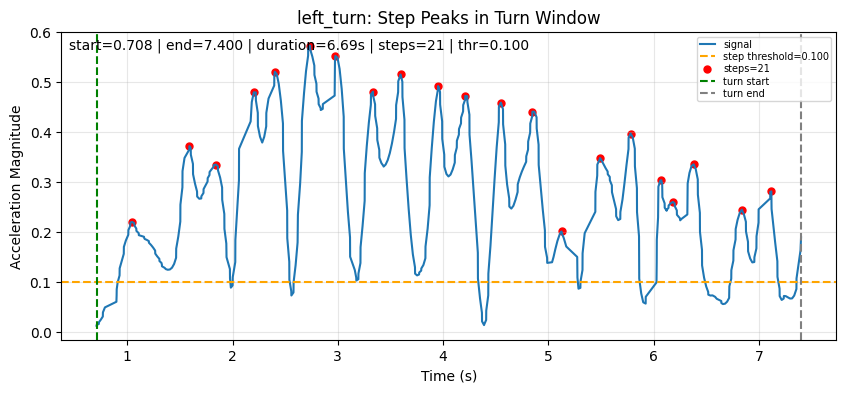

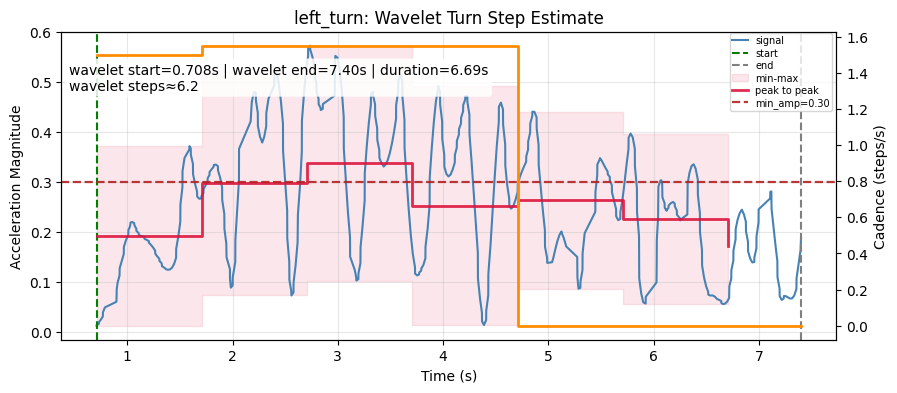

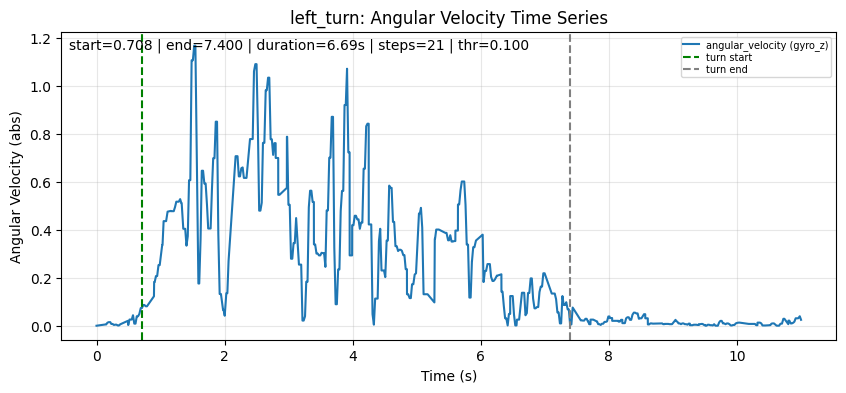

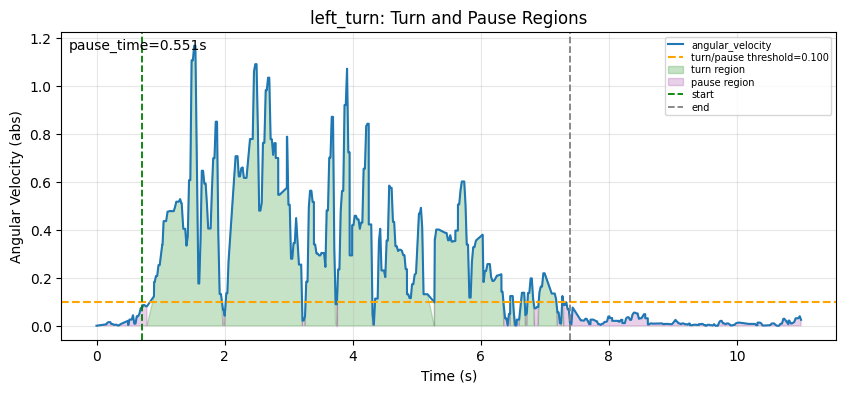

{'activity': 'left_turn', 'start_time_s': 0.7080001831054688, 'end_time_s': 7.400000095367432, 'duration_s': 6.691999912261963, 'step_count': 21, 'wavelet_step_count': 6.150000000000003, 'wavelet_cadence': 55.14046695127264}

[PROCESS] right_turn: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Activity_Data/Organized_Data/SRS08/D1_2025-04-05/360_RightTurn/synchronized/exercise_data_2263_SRS08_synchronized.csv


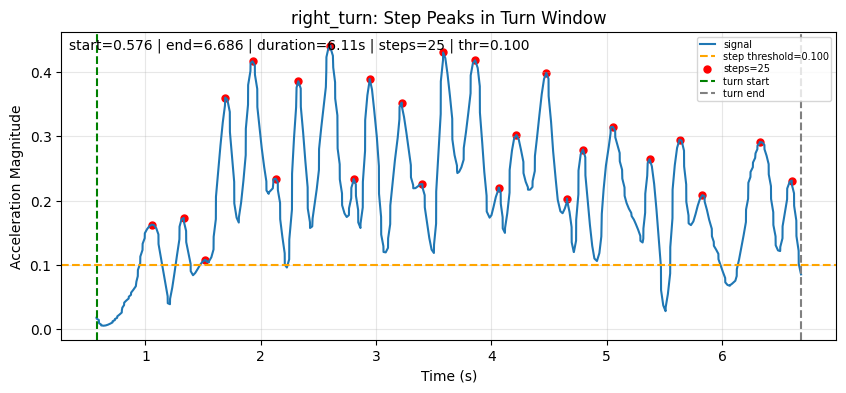

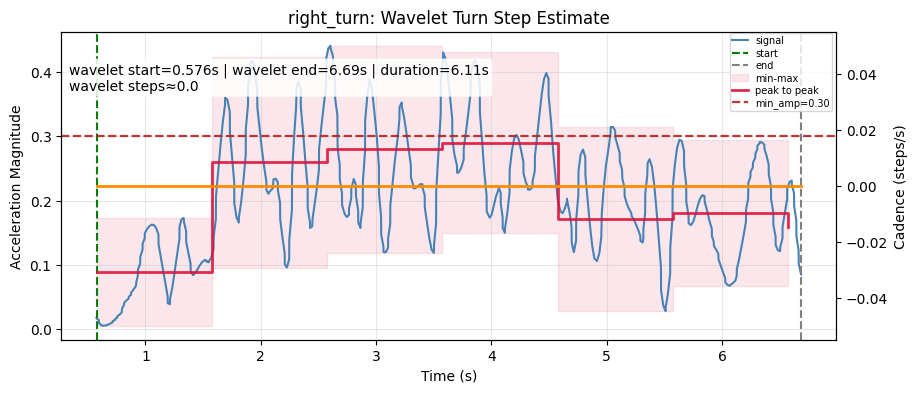

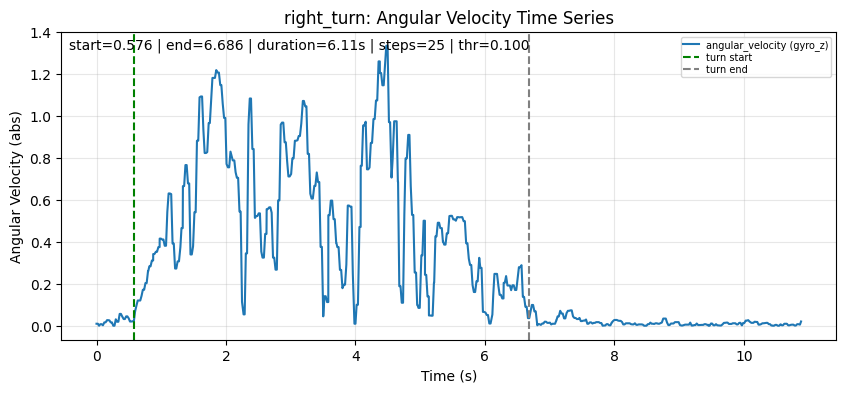

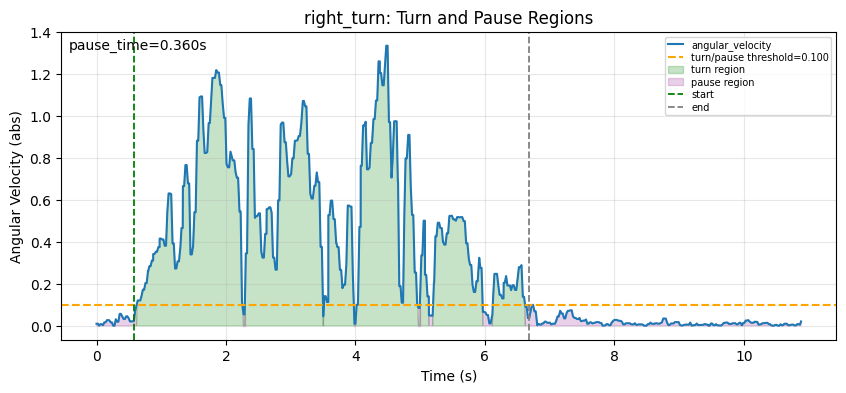

{'activity': 'right_turn', 'start_time_s': 0.5759999752044678, 'end_time_s': 6.685999870300293, 'duration_s': 6.109999895095825, 'step_count': 25, 'wavelet_step_count': 0.0, 'wavelet_cadence': 0.0}


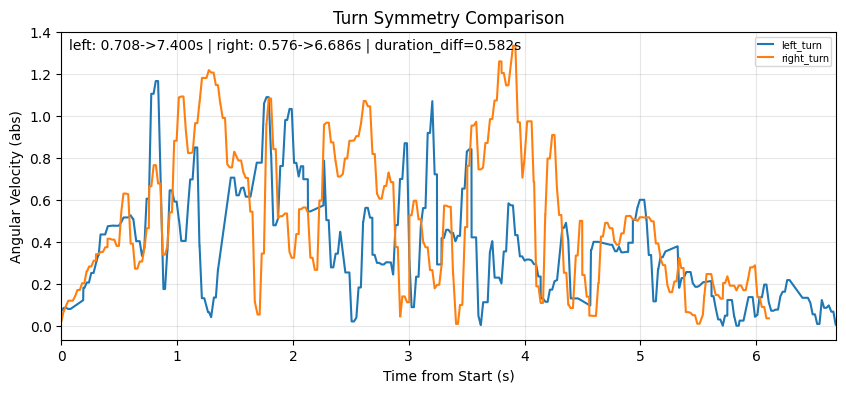

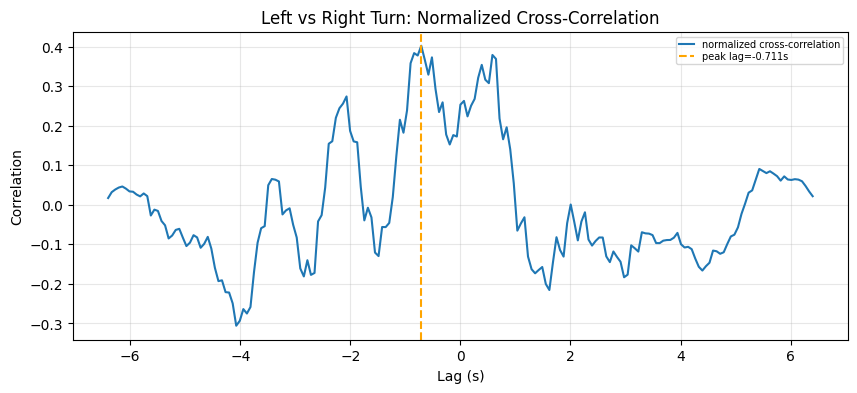

{'activity': 'turn_left_right_xcorr', 'xcorr_peak': 0.40260972402551154, 'xcorr_peak_lag_s': -0.7112222115198772}

=== Validation Summary ===


,activity,start_time_s,end_time_s,duration_s,step_count,wavelet_step_count,wavelet_cadence,xcorr_peak,xcorr_peak_lag_s
0,left_turn,0.708,7.400,6.692,21.0,6.15,55.140467,NaN,NaN
1,right_turn,0.576,6.686,6.110,25.0,0.00,0.000000,NaN,NaN
2,turn_left_right_xcorr,NaN,NaN,NaN,NaN,NaN,NaN,0.40261,-0.711222


In [5]:
sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)

if CHOSEN_DIR is not None:
    BASE_DIR = Path(CHOSEN_DIR)
else:
    BASE_DIR = resolve_date_dir(DATA_ROOT, PATIENT_ID, DATE)
    if DATE is None:
        DATE = BASE_DIR.name

activity_files = discover_activity_files(BASE_DIR, ["left_turn", "right_turn"])

print("Base directory:", BASE_DIR)
print("Discovered activity files:")
for k, v in activity_files.items():
    print(f"  {k}: {v}")

all_summaries = []
turn_cache = {}

for activity in ["left_turn", "right_turn"]:
    if activity not in activity_files:
        print(f"[SKIP] {activity}: not available")
        continue
    path = activity_files[activity]
    print(f"\n[PROCESS] {activity}: {path}")
    df, meta = load_activity_file(path)
    summary, cache = plot_turn_validation(activity, df, meta)
    all_summaries.append(summary)
    turn_cache[activity] = cache
    print(summary)

if "left_turn" in turn_cache and "right_turn" in turn_cache:
    plot_turn_symmetry_comparison(turn_cache["left_turn"], turn_cache["right_turn"])
    turn_corr = plot_turn_pair_xcorr(turn_cache["left_turn"], turn_cache["right_turn"])
    all_summaries.append(turn_corr)
    print(turn_corr)

print("\n=== Validation Summary ===")
display(pd.DataFrame(all_summaries))
